In [1]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
df = pd.read_csv(path + "/sleep_health_dataset.csv", index_col='person_id')
df.head()

100%|██████████| 4.07M/4.07M [00:00<00:00, 52.7MB/s]

Extracting files...


,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
person_id,,,,,,,,,,,,,,,,,,,,,
1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


# Analisis exploratorio
Aplica herramientas de estadística descriptiva para explorar en profundidad el conjunto de datos. Debes:
Describir cada una de las variables (tipos de datos, distribución, valores atípicos, etc.).
Identificar y tratar datos nulos o inconsistentes.
Realizar limpieza de datos si es necesario, cuidando la correcta transformación y codificación de las variables

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

count    100000.000000
mean         34.706870
std          11.036373
min          18.000000
25%          26.000000
50%          33.000000
75%          42.000000
max          69.000000
Name: age, dtype: float64


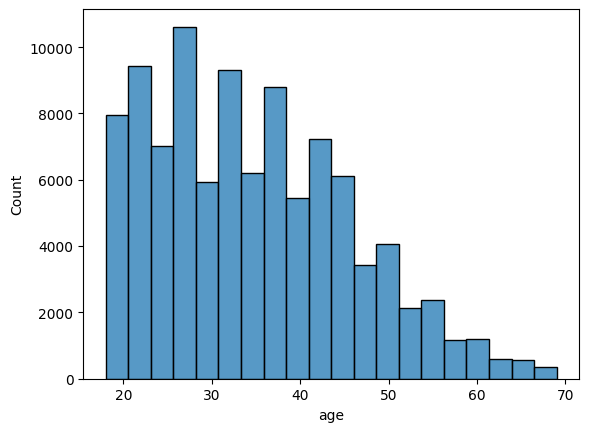

In [7]:
# Analisis de age
print(df['age'].describe())
sns.histplot(df['age'], bins=20)
plt.show()
# plt.hist(df['age'], bins=20)
# plt.show()

gender
Female    50203
Male      47823
Other      1974
Name: count, dtype: int64


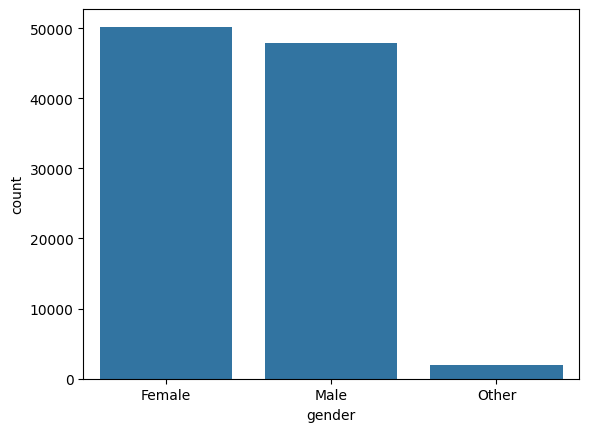

In [8]:
# analisis de gender
print(df['gender'].value_counts())
sns.countplot(x='gender', data=df)
plt.show()

occupation
Student              14851
Software Engineer    12068
Nurse                10073
Manager               8101
Teacher               8047
Doctor                7868
Retired               7036
Sales                 7017
Freelancer            7016
Driver                6996
Homemaker             5923
Lawyer                5004
Name: count, dtype: int64


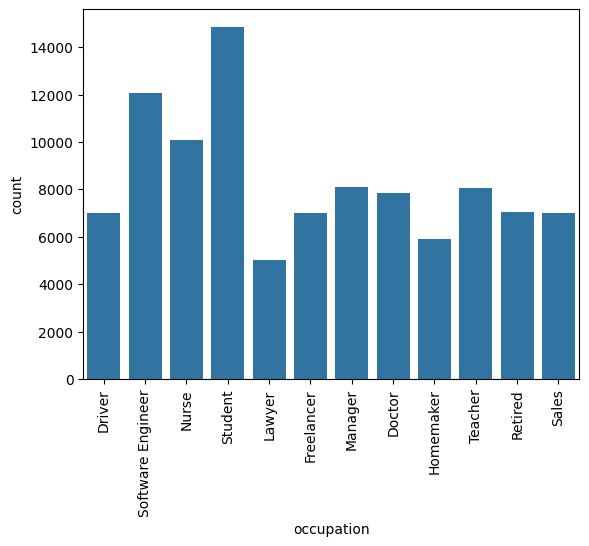

In [14]:
#analisis de occupation
print(df['occupation'].value_counts())
sns.countplot(x='occupation', data=df)
plt.tick_params(axis='x', rotation=90)
plt.show()

count    100000.000000
mean         26.289673
std           4.479578
min          16.000000
25%          23.200000
50%          26.300000
75%          29.300000
max          45.000000
Name: bmi, dtype: float64


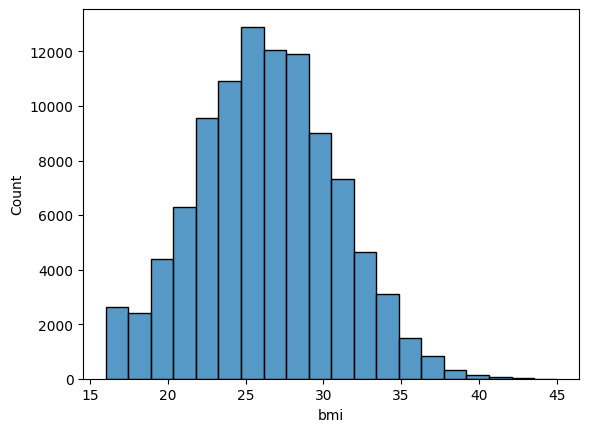

In [15]:
# analisis de bmi
print(df['bmi'].describe())
sns.histplot(df['bmi'], bins=20)
plt.show()

In [9]:
df.columns

Index(['age', 'gender', 'occupation', 'bmi', 'country', 'sleep_duration_hrs',
       'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage',
       'sleep_latency_mins', 'wake_episodes_per_night',
       'caffeine_mg_before_bed', 'alcohol_units_before_bed',
       'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day',
       'nap_duration_mins', 'stress_score', 'work_hours_that_day',
       'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm',
       'sleep_aid_used', 'shift_work', 'room_temperature_celsius',
       'weekend_sleep_diff_hrs', 'season', 'day_type',
       'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested'],
      dtype='object')

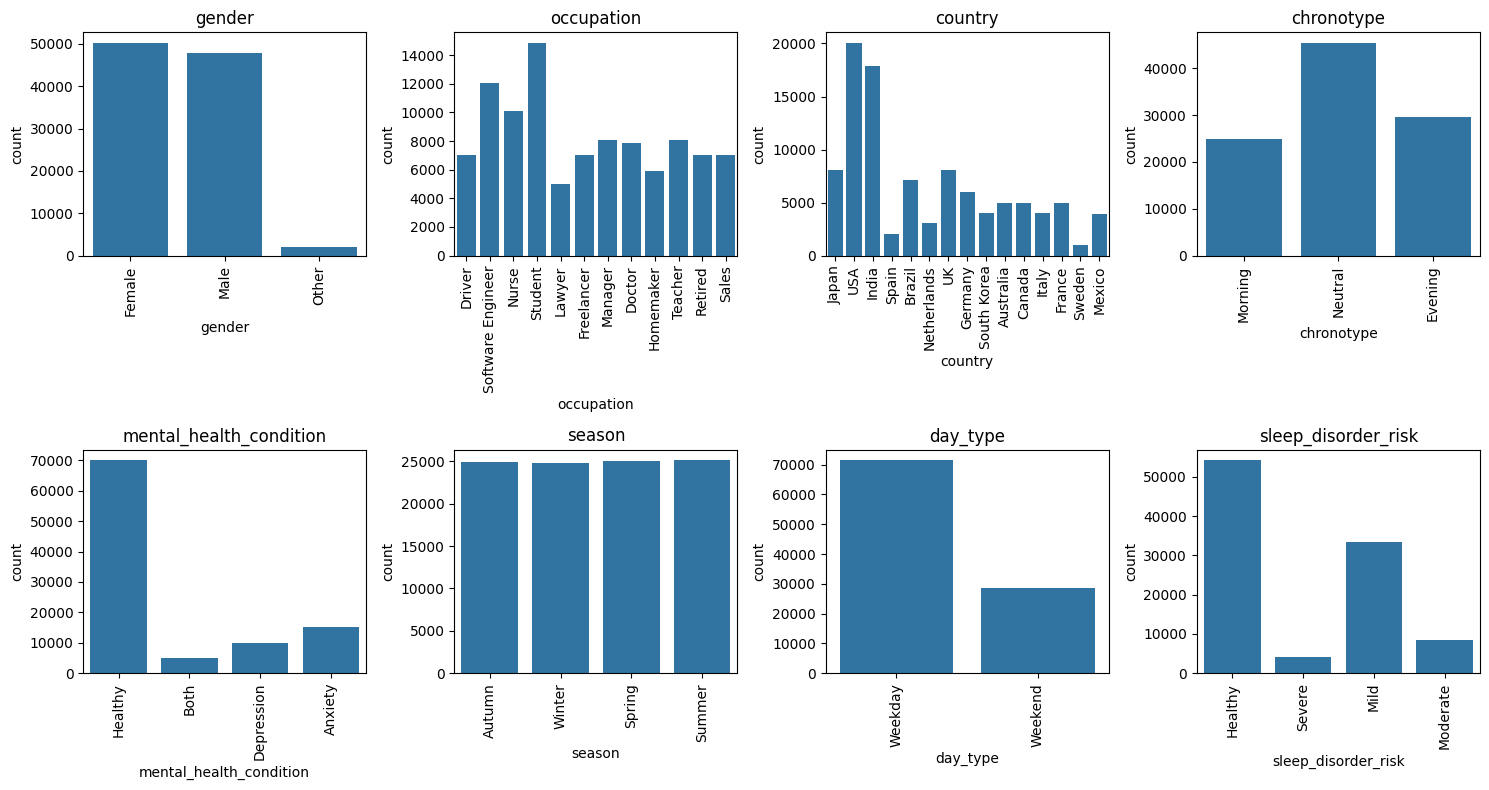

Columnas categóricas: Index(['gender', 'occupation', 'country', 'chronotype',
       'mental_health_condition', 'season', 'day_type', 'sleep_disorder_risk'],
      dtype='object')


In [25]:
# analisis categoricos
categorical_cols = df.select_dtypes(include=["object"]).columns

plt.figure(figsize=(15, 8))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 4, i + 1)
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=90)
    plt.title(col)

#plt.subplot(2, 2, 1)
#sns.countplot(x='gender', data=df)
#plt.title('Gender')

#plt.subplot(2, 2, 2)
#sns.countplot(x='occupation', data=df)
#plt.title('Occupation')
#plt.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()
print("Columnas categóricas:", categorical_cols)

Columnas numéricas: Index(['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score',
       'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used',
       'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs',
       'cognitive_performance_score', 'felt_rested'],
      dtype='object')


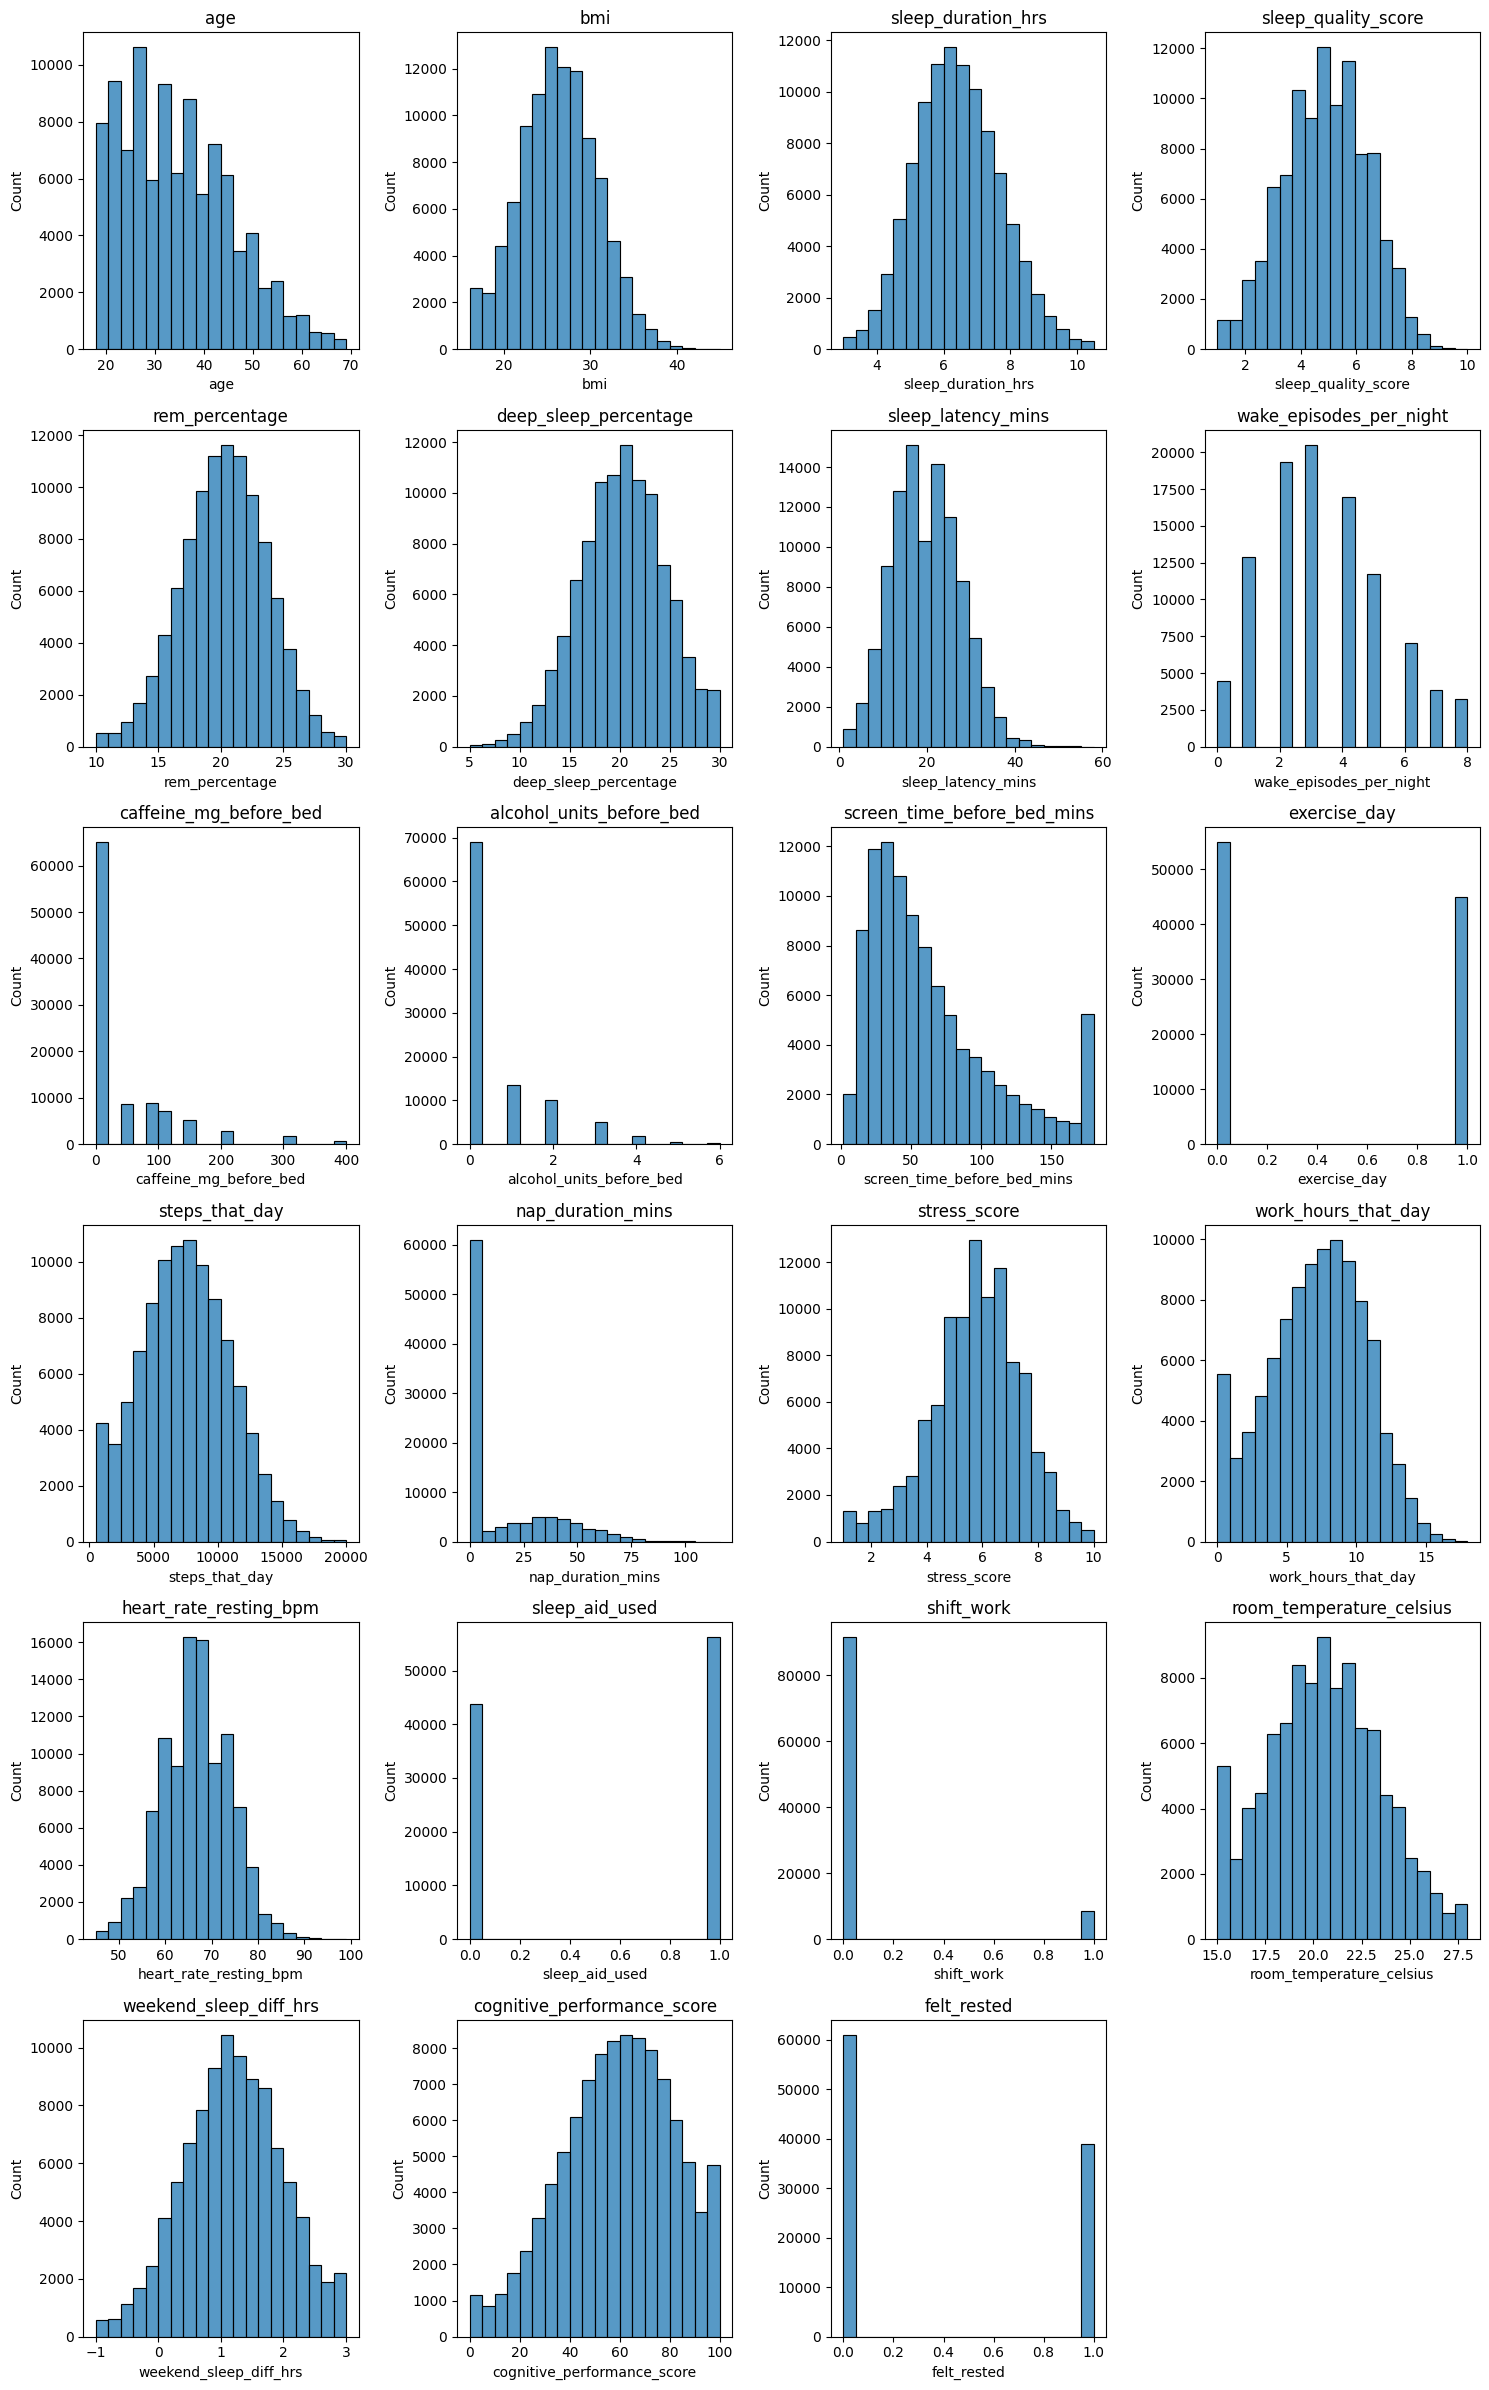

In [31]:
# analisis numericos
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("Columnas numéricas:", numerical_cols)

plt.figure(figsize=(15, 24))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 4, i + 1)
    sns.histplot(x=col, data=df, bins=20)
    plt.xlabel(col)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
X = pd.get_dummies(df.drop(['felt_rested', 'cognitive_performance_score',
                            'sleep_disorder_risk'], axis=1), drop_first=True)
y_bin = df['felt_rested']
y_reg = df['cognitive_performance_score']
y_class = df['sleep_disorder_risk']

# Regresión logística y clasificación simple

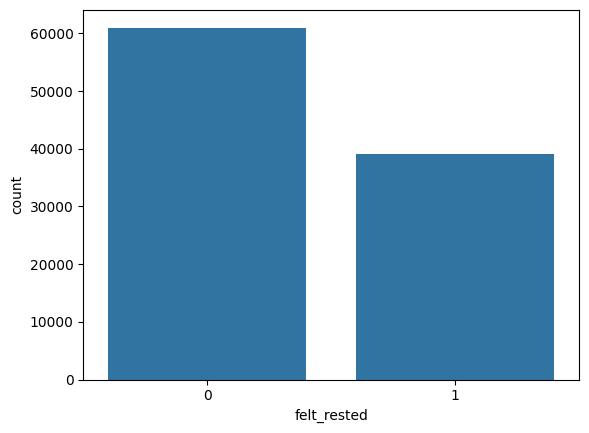

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='felt_rested', data=df)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)

## Sin modificar ni nada

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

forest_model = RandomForestClassifier()
forest_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)
y_pred_forest = forest_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic regression accuracy: 0.7087
KNN accuracy: 0.5633
Decision tree accuracy: 0.6643
Random forest accuracy: 0.7396


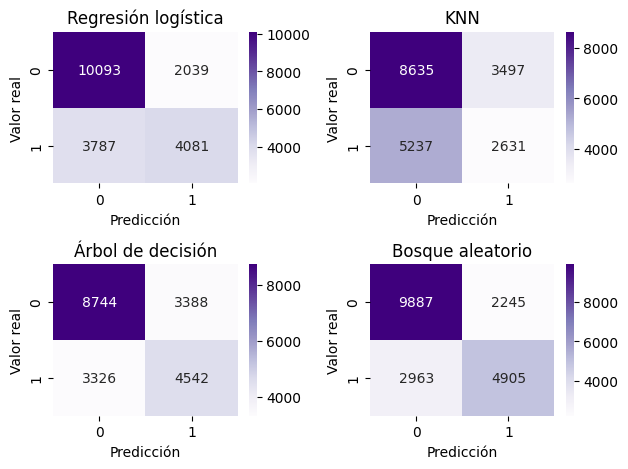

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

report_log = classification_report(y_test, y_pred_log, output_dict=True)
print(f'Logistic regression accuracy: {report_log['accuracy']}')

report_knn = classification_report(y_test, y_pred_knn, output_dict=True)
print(f'KNN accuracy: {report_knn['accuracy']}')

report_tree = classification_report(y_test, y_pred_tree, output_dict=True)
print(f'Decision tree accuracy: {report_tree['accuracy']}')

report_forest = classification_report(y_test, y_pred_forest, output_dict=True)
print(f'Random forest accuracy: {report_forest['accuracy']}')

plt.subplot(2, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='.0f', cmap='Purples')
plt.title('Regresión logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='.0f', cmap='Purples')
plt.title('KNN')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 3)
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='.0f', cmap='Purples')
plt.title('Árbol de decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 4)
sns.heatmap(confusion_matrix(y_test, y_pred_forest), annot=True, fmt='.0f', cmap='Purples')
plt.title('Bosque aleatorio')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train_scaled, y_train)

forest_model = RandomForestClassifier()
forest_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_tree = tree_model.predict(X_test_scaled)
y_pred_forest = forest_model.predict(X_test_scaled)

Logistic regression accuracy: 0.738
KNN accuracy: 0.6771
Decision tree accuracy: 0.6643
Random forest accuracy: 0.7422


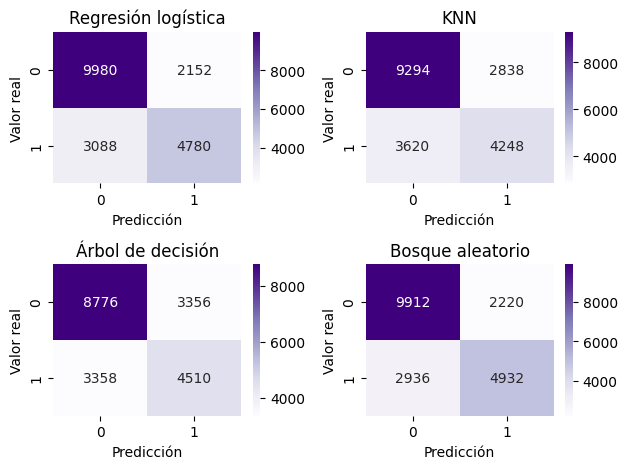

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

report_log = classification_report(y_test, y_pred_log, output_dict=True)
print(f'Logistic regression accuracy: {report_log['accuracy']}')

report_knn = classification_report(y_test, y_pred_knn, output_dict=True)
print(f'KNN accuracy: {report_knn['accuracy']}')

report_tree = classification_report(y_test, y_pred_tree, output_dict=True)
print(f'Decision tree accuracy: {report_tree['accuracy']}')

report_forest = classification_report(y_test, y_pred_forest, output_dict=True)
print(f'Random forest accuracy: {report_forest['accuracy']}')

plt.subplot(2, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='.0f', cmap='Purples')
plt.title('Regresión logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='.0f', cmap='Purples')
plt.title('KNN')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 3)
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='.0f', cmap='Purples')
plt.title('Árbol de decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 4)
sns.heatmap(confusion_matrix(y_test, y_pred_forest), annot=True, fmt='.0f', cmap='Purples')
plt.title('Bosque aleatorio')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.tight_layout()
plt.show()

# Regresión lineal

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

MSE: 49.51624612300319
R2: 0.8992385078929722
MAE: 5.529094293415574


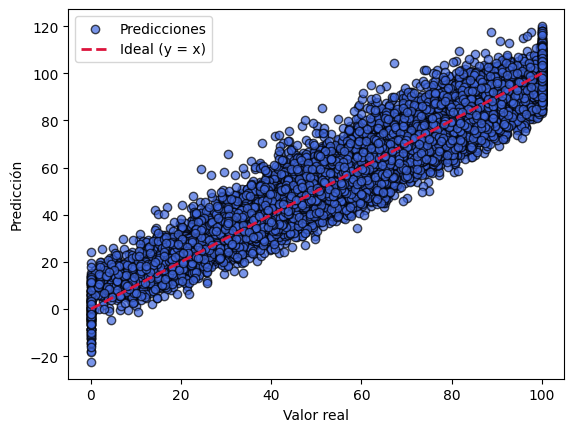

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'MSE: {mse}')
print(f'R2: {r2}')
print(f'MAE: {mae}')

plt.scatter(y_test, y_pred, color="royalblue", alpha=0.7, edgecolor="k", label="Predicciones")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="crimson", lw=2, linestyle="--", label="Ideal (y = x)")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.legend()
plt.show()

# Clasificación (4 clases)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = tree_model.predict(X_test)

              precision    recall  f1-score   support

     Healthy       0.98      0.98      0.98     10892
        Mild       0.89      0.88      0.89      6673
    Moderate       0.56      0.59      0.58      1626
      Severe       0.71      0.70      0.71       809

    accuracy                           0.90     20000
   macro avg       0.78      0.79      0.79     20000
weighted avg       0.90      0.90      0.90     20000



<Axes: >

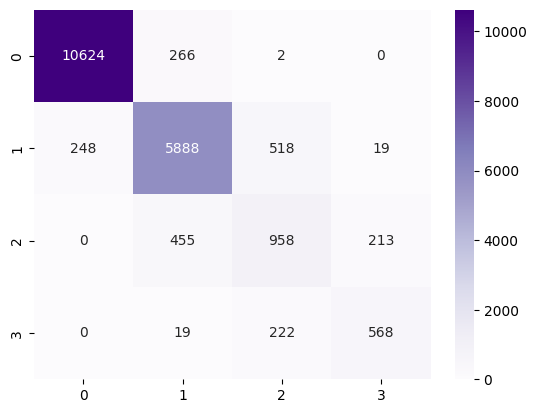

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.0f', cmap='Purples')